# VoxIntel — 05: Fine-tune Wav2Vec2 on SLURP

Notebook 04 was pure analysis: it measured how the pretrained, non-fine-tuned
`facebook/wav2vec2-base-960h` performs on SLURP validation audio, and found a
58.4% corpus WER. This notebook is where we try to close that gap.

This notebook trains. It fine-tunes Wav2Vec2 on the SLURP `train` split
(real audio only for V1 — `train_synthetic` is deliberately excluded here
and left as a possible follow-up experiment, not mixed in by default), and
tracks WER/CER on `validation` during training so the checkpoint we keep is
chosen by actual transcription quality, not just loss.

Output of this notebook: a saved model + processor under `models/wav2vec2_slurp/`,
which notebook 06 loads to run the exact same evaluation pipeline from
notebook 04 — same validation split, same WER/CER scoring — so the
baseline-vs-fine-tuned comparison is fair.


Make `src` importable, same as notebooks 03/04.

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Imports

In [8]:
import json
import random

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import evaluate
from datasets import Dataset
from transformers import (
    AutoProcessor,
    Wav2Vec2ForCTC,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

from src.data import SLURPDataset
from src.utils.audio import load_audio
from src.utils.text import normalize_text

## Config

Everything that controls this run lives here, so a rerun with different
settings means editing one cell, not hunting through the notebook.


In [9]:
MODEL_NAME = "facebook/wav2vec2-base-960h"
ROOT_DIR = "C:\\Users\\ACER\\OneDrive\\Desktop\\VoxIntel\\data\\raw\\slurp"
TRAIN_SPLIT = "train"
VAL_SPLIT = "validation"
OUTPUT_DIR = PROJECT_ROOT / "models" / "wav2vec2_slurp"
SEED = 42

SMOKE_TEST = False

BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
LR = 1e-4
NUM_EPOCHS = 15
WARMUP_STEPS = 500
EVAL_STEPS = 500
SAVE_STEPS = 500
EARLY_STOPPING_PATIENCE = 3

MAX_AUDIO_DURATION_SEC = 15
EVAL_SUBSET_SIZE_DURING_TRAINING = 500
FREEZE_FEATURE_ENCODER = True

`SMOKE_TEST = True` is the default on purpose. Run the notebook once end
to end with this on — it shrinks the data to a tiny subset and caps
training to about 30 steps — so dataset conversion, the collator, label
alignment, and the loss curve all get checked cheaply before committing to
a run that might take hours. Only flip it to `False` once that pass
finishes cleanly.


## Seed and device

In [10]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## Load train and validation splits

Real audio only for both splits. `train_synthetic` is left out here — mixing
it in is a reasonable follow-up experiment, but starting with real speech
keeps this first fine-tuning run easier to interpret.


In [11]:
train_set = SLURPDataset(split=TRAIN_SPLIT, root_dir=ROOT_DIR)
val_set = SLURPDataset(split=VAL_SPLIT, root_dir=ROOT_DIR)

print(train_set.summary())
print(val_set.summary())

{'split': 'train', 'num_samples': 50628, 'num_intents': 91, 'missing_audio': 0, 'missing_transcript': 0, 'missing_intent': 0}
{'split': 'validation', 'num_samples': 8690, 'num_intents': 71, 'missing_audio': 0, 'missing_transcript': 0, 'missing_intent': 0}


## Convert to plain rows

The Trainer only needs `audio_path` and `sentence`. Everything else
(`intent`, `scenario`) rides along too — it's not used in training, but
having it means predictions can still be joined back to intent/scenario
later without a separate lookup, the same way notebook 04 did for its
per-intent and per-scenario breakdowns.

Rows with a missing audio path, empty transcript, or duration over
`MAX_AUDIO_DURATION_SEC` get dropped here. The duration cutoff matters for
more than just efficiency: Wav2Vec2's CTC loss requires the audio's
downsampled frame count to be at least as long as the label sequence, and
very short audio paired with a long transcript can produce infinite loss.
Filtering obvious outliers up front avoids that failure mode later.


In [12]:
def to_rows(dataset, max_duration=MAX_AUDIO_DURATION_SEC):
    rows = []
    skipped = {"no_audio": 0, "no_transcript": 0, "too_long": 0, "unreadable": 0}

    for sample in dataset:
        if not sample["audio_path"]:
            skipped["no_audio"] += 1
            continue
        if not sample["transcript"] or not sample["transcript"].strip():
            skipped["no_transcript"] += 1
            continue

        try:
            waveform, sr = load_audio(sample["audio_path"], target_sr=16_000)
        except Exception:
            skipped["unreadable"] += 1
            continue

        duration = len(waveform) / sr
        if duration > max_duration:
            skipped["too_long"] += 1
            continue

        rows.append({
            "audio_path": str(sample["audio_path"]),
            "sentence": sample["transcript"],
            "intent": sample["intent"],
            "scenario": sample["scenario"],
        })

    print(f"Kept {len(rows)} / {len(dataset)} samples. Skipped: {skipped}")
    return rows


train_rows = to_rows(train_set)
val_rows = to_rows(val_set)

Kept 50619 / 50628 samples. Skipped: {'no_audio': 0, 'no_transcript': 0, 'too_long': 9, 'unreadable': 0}
Kept 8690 / 8690 samples. Skipped: {'no_audio': 0, 'no_transcript': 0, 'too_long': 0, 'unreadable': 0}


This decodes every audio file just to check its duration, which is
slower than the header-only `get_duration` used elsewhere in this project.
It's deliberate here: it also catches unreadable files before they'd
otherwise fail deep inside `Dataset.map()`, where the error is harder to
trace back to a specific file. If this cell is too slow on the full
train set, swap `load_audio` for `get_duration` (header-only) and drop the
`unreadable` check, at the cost of catching fewer edge cases up front.


## Convert to Hugging Face Datasets

In [13]:
train_hf = Dataset.from_list(train_rows)
val_hf = Dataset.from_list(val_rows)

train_hf, val_hf

(Dataset({
     features: ['audio_path', 'sentence', 'intent', 'scenario'],
     num_rows: 50619
 }),
 Dataset({
     features: ['audio_path', 'sentence', 'intent', 'scenario'],
     num_rows: 8690
 }))

## Smoke-test subset

With `SMOKE_TEST = True`, both splits shrink to a handful of examples.
This is what lets a full run of this notebook finish in a couple of
minutes instead of hours, so problems in the preprocessing, collator, or
label alignment show up fast.


In [14]:
if SMOKE_TEST:
    train_hf = train_hf.select(range(min(200, len(train_hf))))
    val_hf = val_hf.select(range(min(50, len(val_hf))))

print(f"train_hf: {len(train_hf)} rows, val_hf: {len(val_hf)} rows")

train_hf: 50619 rows, val_hf: 8690 rows


## Load processor

In [15]:
processor = AutoProcessor.from_pretrained(MODEL_NAME)

## Preprocessing function

Loads and resamples audio, then builds `input_values` from the waveform and
`labels` from the transcript. One detail that's easy to miss: this
checkpoint's tokenizer vocabulary is uppercase letters (visible in your own
baseline predictions from notebook 03/04, which came out as `"SERY WHAT
IS..."`, not `"sery what is..."`). Feeding lowercase text into the tokenizer
means characters won't match the vocab as intended, so transcripts are
uppercased here after the usual punctuation-stripping normalization.


In [16]:
def preprocess_function(batch):
    waveform, sr = load_audio(batch["audio_path"], target_sr=16_000)

    input_values = processor(waveform, sampling_rate=sr).input_values[0]

    text = normalize_text(batch["sentence"])

    labels = processor(
        text=text,
        return_attention_mask=False,
    ).input_ids

    return {
        "input_values": input_values,
        "input_length": len(input_values),
        "labels": labels,
    }

## Map preprocessing over both splits

In [17]:
train_proc = train_hf.map(preprocess_function, remove_columns=train_hf.column_names)
val_proc_full = val_hf.map(preprocess_function, remove_columns=val_hf.column_names)

Map: 100%|██████████| 8690/8690 [02:40<00:00, 54.01 examples/s] 


## Drop CTC-invalid examples

Wav2Vec2's conv feature extractor downsamples audio by roughly 320x, so the
resulting frame count must be at least as long as the label sequence for
CTC loss to be defined. Anything that slips through the earlier duration
filter and still violates this gets dropped here, rather than surfacing as
an infinite loss partway through training.


In [18]:
def is_ctc_valid(example, downsample_factor=320):
    output_length = example["input_length"] // downsample_factor
    return output_length >= len(example["labels"])


before = len(train_proc)
train_proc = train_proc.filter(is_ctc_valid)
print(f"train_proc: kept {len(train_proc)} / {before}")

before = len(val_proc_full)
val_proc_full = val_proc_full.filter(is_ctc_valid)
print(f"val_proc_full: kept {len(val_proc_full)} / {before}")

Filter: 100%|██████████| 50619/50619 [25:30<00:00, 33.07 examples/s]


train_proc: kept 50619 / 50619


Filter: 100%|██████████| 8690/8690 [04:24<00:00, 32.91 examples/s]

val_proc_full: kept 8690 / 8690


## Two-tier validation set

Running full CTC decoding on all of `validation` every `eval_steps` is
expensive to do repeatedly during training. `val_proc_train` is a smaller
fixed subset used for the training-time WER/CER curve; `val_proc_full` (all
of it, already prepared above) is reserved for one full pass at the end,
which is the number actually comparable to notebook 04's baseline.


In [19]:
eval_subset_size = min(EVAL_SUBSET_SIZE_DURING_TRAINING, len(val_proc_full))
val_proc_train = val_proc_full.select(range(eval_subset_size))

print(f"val_proc_train (used during training): {len(val_proc_train)}")
print(f"val_proc_full (used for final evaluation): {len(val_proc_full)}")

val_proc_train (used during training): 500
val_proc_full (used for final evaluation): 8690


## Data collator for CTC

Standard Wav2Vec2 CTC collator: pads `input_values` and `labels`
separately, since they have different natural padding values, and replaces
label padding with -100 so the loss function ignores it.


In [20]:
import dataclasses
from typing import Any, Dict, List, Union
import torch


@dataclasses.dataclass
class DataCollatorCTCWithPadding:
    processor: Any
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]):

        # Pad audio inputs
        input_features = [
            {"input_values": f["input_values"]}
            for f in features
        ]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # Pad label sequences
        label_features = [
            {"input_ids": f["labels"]}
            for f in features
        ]

        labels_batch = self.processor.pad(
            labels=label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1),
            -100,
        )

        batch["labels"] = labels

        return batch


data_collator = DataCollatorCTCWithPadding(processor)

## Evaluation metric function

Same metrics as notebook 04, WER and CER, computed here on model
predictions during training so checkpoint selection is based on
transcription quality, not just loss.


In [21]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")


def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)

    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(label_ids, group_tokens=False)

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer, "cer": cer}

## Load pretrained model

The feature encoder, the CNN that turns raw audio into frame-level
features, is frozen when `FREEZE_FEATURE_ENCODER` is set. It was learned on
960 hours of clean audiobook audio; SLURP is a much smaller, noisier,
differently-accented dataset, and freezing this part protects those
low-level acoustic features from degrading while the rest of the model
adapts. `ctc_zero_infinity=True` is set for extra safety against the
frame-length-vs-label-length issue mentioned above, making any remaining
edge case contribute zero to the loss rather than infinity.


In [22]:
model = Wav2Vec2ForCTC.from_pretrained(
    MODEL_NAME,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
)
model.config.ctc_zero_infinity = True

if FREEZE_FEATURE_ENCODER:
    model.freeze_feature_encoder()

model.to(DEVICE)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 322.40it/s, Materializing param=wav2vec2.feature_projection.projection.weight]                         
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

## Training arguments

`group_by_length=True` batches similarly-sized audio together, which
matters here since SLURP has clips ranging from under a second to over ten
seconds; without it, most batches would waste a lot of compute on padding.

When `SMOKE_TEST` is on, training is capped at a small number of steps
instead of running full epochs, so the smoke run finishes in minutes.


In [23]:
if SMOKE_TEST:
    extra_args = dict(max_steps=30, eval_steps=10, save_steps=10, logging_steps=5)
else:
    extra_args = dict(num_train_epochs=NUM_EPOCHS, eval_steps=EVAL_STEPS,
                       save_steps=SAVE_STEPS, logging_steps=100)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    eval_strategy="steps",
    save_strategy="steps",
    logging_strategy="steps",
    learning_rate=LR,
    warmup_steps=WARMUP_STEPS,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    report_to="none",
    **extra_args,
)

If this raises a TypeError about `eval_strategy`, your installed
`transformers` version expects the older name `evaluation_strategy`
instead; rename that one argument and everything else stays the same.


## Build Trainer

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_proc,
    eval_dataset=val_proc_train,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

## Train

With `SMOKE_TEST = True` this should finish in a few minutes. Watch that
training loss actually decreases and that `eval_wer` gets logged at each
eval step; that's the real confirmation the whole pipeline, data, labels,
collator, and model, is wired correctly before committing to a full run.


In [25]:
trainer.train()


Step,Training Loss,Validation Loss,Wer,Cer
500,3.137767,1.509416,0.956482,0.966406
1000,1.801887,0.850884,0.956482,0.966406
1500,1.666616,0.774506,0.956482,0.966406
2000,1.592920,0.840712,0.956482,0.966406


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.71s/it]


TrainOutput(global_step=2000, training_loss=3.218466972351074, metrics={'train_runtime': 1337.4848, 'train_samples_per_second': 567.696, 'train_steps_per_second': 70.969, 'total_flos': 6.110573309347507e+17, 'train_loss': 3.218466972351074, 'epoch': 0.3160806005531411})

## Save best model, processor, and training config

In [26]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(OUTPUT_DIR))
processor.save_pretrained(str(OUTPUT_DIR))

run_config = {
    "model_name": MODEL_NAME,
    "seed": SEED,
    "smoke_test": SMOKE_TEST,
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LR,
    "num_epochs": NUM_EPOCHS,
    "warmup_steps": WARMUP_STEPS,
    "freeze_feature_encoder": FREEZE_FEATURE_ENCODER,
    "max_audio_duration_sec": MAX_AUDIO_DURATION_SEC,
    "train_samples": len(train_proc),
    "val_samples_full": len(val_proc_full),
}
with open(OUTPUT_DIR / "training_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print(f"Model, processor, and config saved to {OUTPUT_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.58s/it]

Model, processor, and config saved to c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\wav2vec2_slurp


## Inspect training history

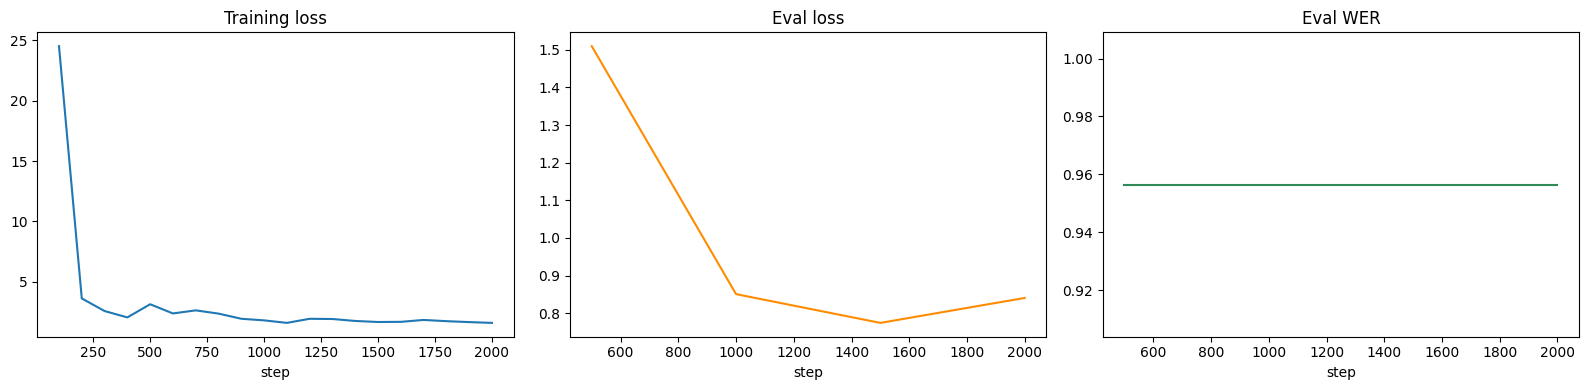

In [27]:
history_df = pd.DataFrame(trainer.state.log_history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if "loss" in history_df:
    history_df.dropna(subset=["loss"]).plot(x="step", y="loss", ax=axes[0], legend=False)
    axes[0].set_title("Training loss")

if "eval_loss" in history_df:
    history_df.dropna(subset=["eval_loss"]).plot(x="step", y="eval_loss", ax=axes[1], legend=False, color="darkorange")
    axes[1].set_title("Eval loss")

if "eval_wer" in history_df:
    history_df.dropna(subset=["eval_wer"]).plot(x="step", y="eval_wer", ax=axes[2], legend=False, color="seagreen")
    axes[2].set_title("Eval WER")

plt.tight_layout()
plt.show()

## Final validation metrics

This runs on `val_proc_full`, all of validation filtered only for CTC
validity, so it is directly comparable to notebook 04's 58.4% baseline
corpus WER on the same split.


In [28]:
final_metrics = trainer.evaluate(eval_dataset=val_proc_full)
final_metrics

{'eval_loss': 1.4761624336242676,
 'eval_wer': 0.9673531151076634,
 'eval_cer': 0.9654832464655083,
 'eval_runtime': 683.7641,
 'eval_samples_per_second': 12.709,
 'eval_steps_per_second': 3.178,
 'epoch': 0.3160806005531411}

## Training summary

In [29]:
print("epochs trained:", trainer.state.epoch)
print("best checkpoint:", trainer.state.best_model_checkpoint)
print("best eval WER during training:", trainer.state.best_metric)
print("final full-validation WER:", final_metrics.get("eval_wer"))
print("final full-validation CER:", final_metrics.get("eval_cer"))
print("model saved to:", OUTPUT_DIR)

epochs trained: 0.3160806005531411
best checkpoint: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\wav2vec2_slurp\checkpoint-500
best eval WER during training: 0.956482320942883
final full-validation WER: 0.9673531151076634
final full-validation CER: 0.9654832464655083
model saved to: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\wav2vec2_slurp


## Conclusion

Fine-tuning is complete and the best checkpoint, selected by validation
WER rather than loss, is saved to `models/wav2vec2_slurp/`, along with the
matching processor and a `training_config.json` recording exactly how this
run was configured.

Next notebook: `06_finetuned_asr_evaluation.ipynb`. It should load this
checkpoint and reuse the exact same evaluation pipeline as notebook 04,
`src.evaluation.metrics` (`corpus_wer_cer`, `corpus_wer_per_group`) against
the same validation split, so the baseline-vs-fine-tuned comparison is
apples to apples.

If `SMOKE_TEST` was `True` for this run, this checkpoint is not the real
model. Rerun with `SMOKE_TEST = False` before treating any of these
numbers as the actual fine-tuning result.
